In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]

import pandas as pd 
import numpy as np 
import os 
import importlib

import cleaning as clean
import abc_models 
import synthetic_data

importlib.reload(synthetic_data); importlib.reload(abc_models);

#### 1. Load the signature data, use the cleaning functions.

In [2]:
data_path_signatures = os.path.abspath("../data/Context_SBS_2.txt")
sig_df = pd.read_csv(data_path_signatures, sep = ",")
clean_sig_df = clean.clean_sigs(sig_df)
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


---

#### 2. Check the function `compare_alpha()` works as intended, then look at `abc_alpha_inference()`.

It takes an injection level, a baseline signature, and tests the hypothesis that this baseline signature was derived from the profile $\alpha SBS88 + (1-\alpha)healthyColon$.

In [3]:
# Test the ABC alpha comparison.
healthy_profile = clean_sig_df["Normal"]
sbs88_profile = clean_sig_df["SBS88"]
test_sig = synthetic_data.generate_signature(healthy_profile, N_muts = 100)

abc_models.compare_alpha(test_sig, healthy_profile, sbs88_profile,
                         alpha = 0.5, N_muts = 100, tol = 0.25)

np.float64(0.145)

Low probability --> it is unlikely our healthy signature was derived with $alpha = 0.5$. This idea is generalised in the `abc_alpha_inference()` wherein we normalise the probabilities that a signature was generated **across a range of** $\alpha$'s.

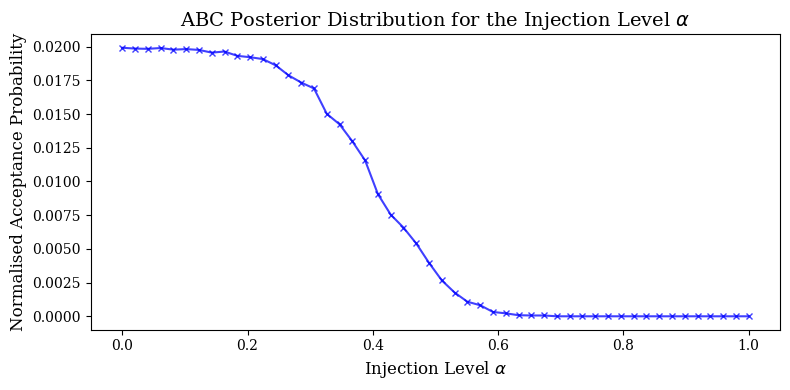

In [ ]:
# EXAMPLE WITH 100 MUTATIONS, test signature is HEALTHY (alpha = 0).
importlib.reload(abc_models);
_, _ = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = 100, plot = True)

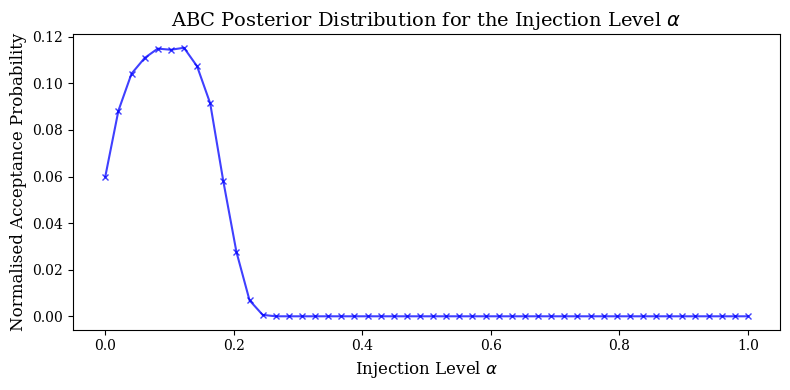

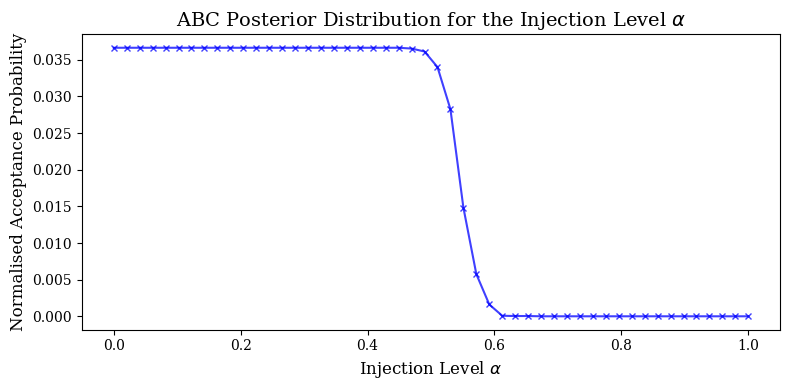

In [38]:
# ANOTHER EXAMPLE WITH 1000 MUTATIONS, TEST SIGNATURE HAS ALPHA = 0.01
# IMPORTANTLY HERE WE VARY THE TOLERANCE (IT IS IMPORTANT!)
importlib.reload(synthetic_data); importlib.reload(abc_models);
alpha01_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.1)
test_sig2 = synthetic_data.generate_signature(alpha01_profile, N_muts = 1000)

__, __ = abc_models.abc_alpha_inference(test_sig2, healthy_profile, sbs88_profile, N_muts = 1000, tol = 0.025, plot = True)
__, __ = abc_models.abc_alpha_inference(test_sig2, healthy_profile, sbs88_profile, N_muts = 1000, tol = 0.25, plot = True)

Discussion: it works as expected, but the choice of tolerance is very important. (Next section discusses how we can choose the optimal tolerance). 

To obtain more of a "classifier", or similar, we should look to construct confidence intervals for $\alpha$ arising from the posterior. If confidence interval doesn't include zero, that indicates significant evidence SBS88 is present.

---
---

#### 3. Find the optimal tolerance through TPR - FPR analysis.

Expect the tolerance to decrease as the number of mutations increases, want to see how it behaves across different alphas.

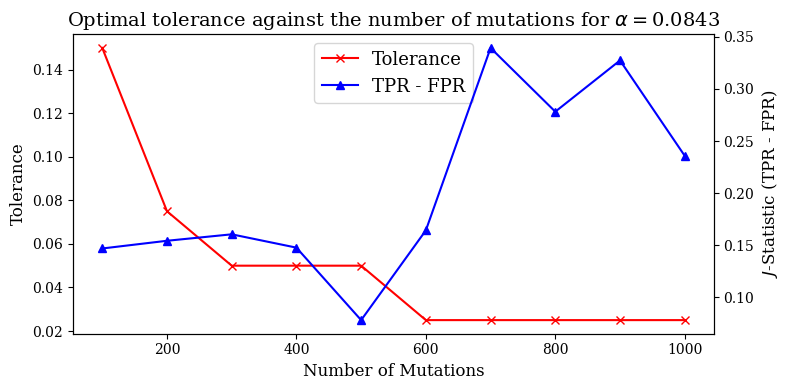

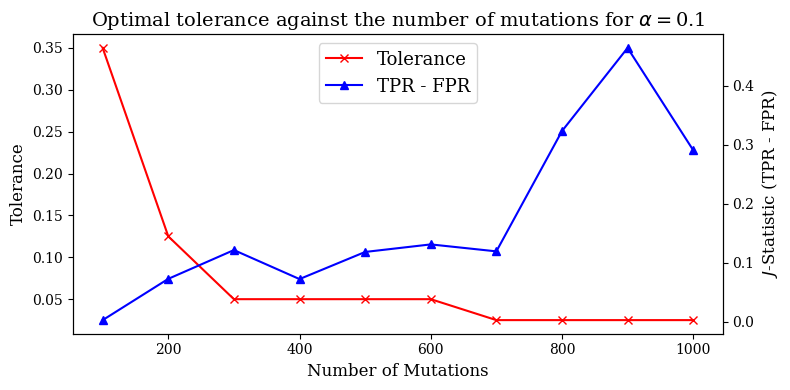

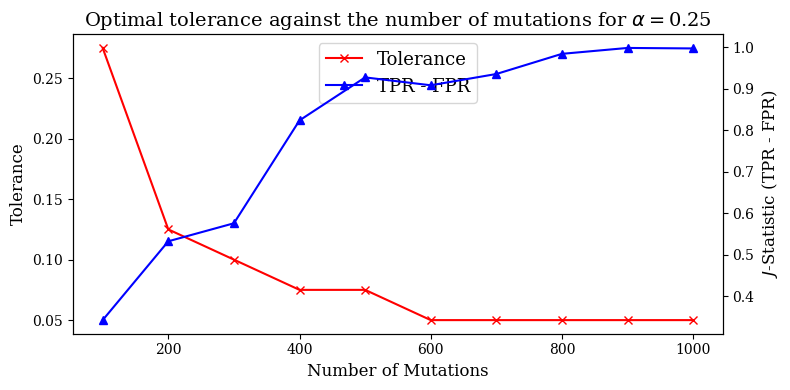

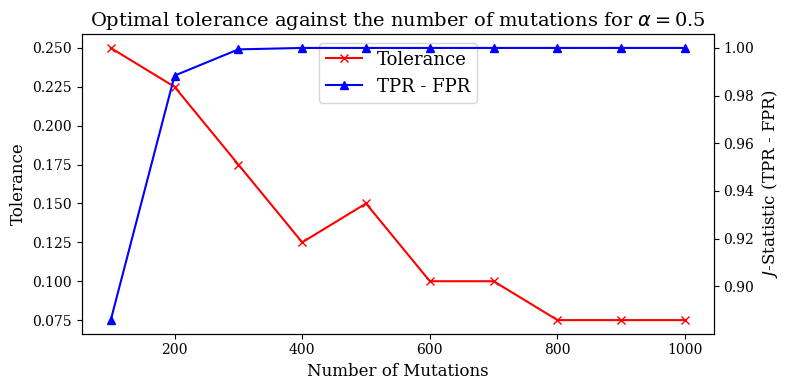

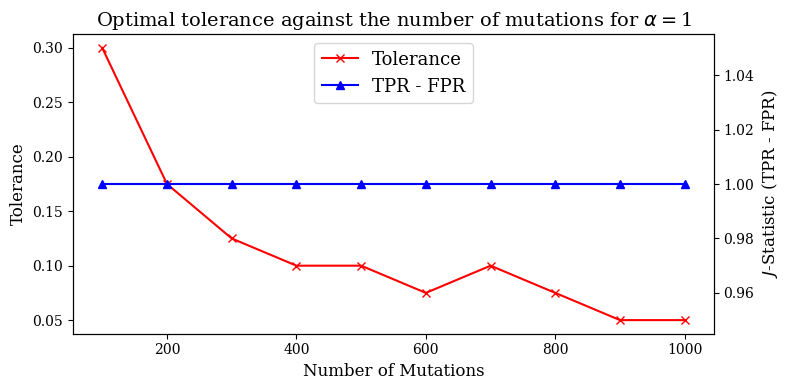

In [9]:
N_muts_range = np.arange(100, 1000 + 100, 100) # 100, 200, ..., 1000
for alpha_test in [0.0843, 0.1, 0.25, 0.5, 1]:
    abc_models.optimal_alpha_tol(healthy_profile, sbs88_profile, alpha_test, N_muts_range, plot = True)

In general, best tolerance decreases when we have higher resolution (higher number of mutations). Unfortunately it's very noisy for $\alpha = 0.0843$, try again with more mutations?

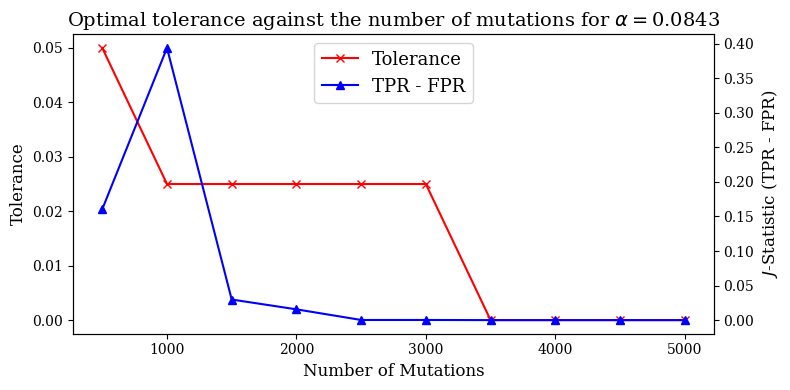

In [10]:
N_muts_alpha0843 = np.arange(500, 5000 + 500, 500)
__ = abc_models.optimal_alpha_tol(healthy_profile, sbs88_profile, alpha = 0.0843, N_muts_range = N_muts_alpha0843, plot = True)

Score vanishes! Why? Maybe because $\alpha$ is too low and we cannot differentiate between the signatures at all?

Plot the signatures generated from a healthy signature and a low-$\alpha$ signature to see why this might be happening?

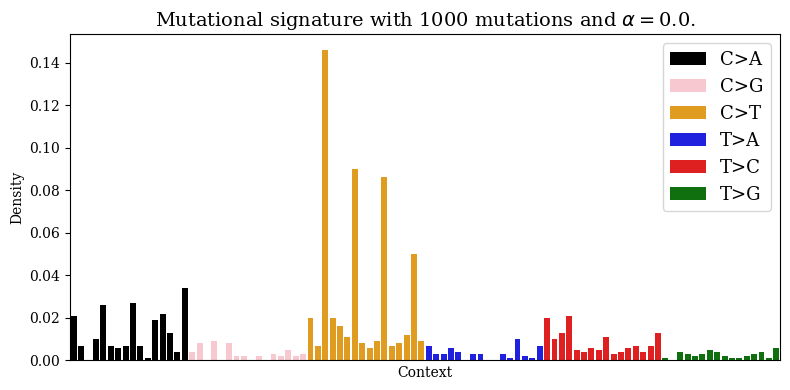

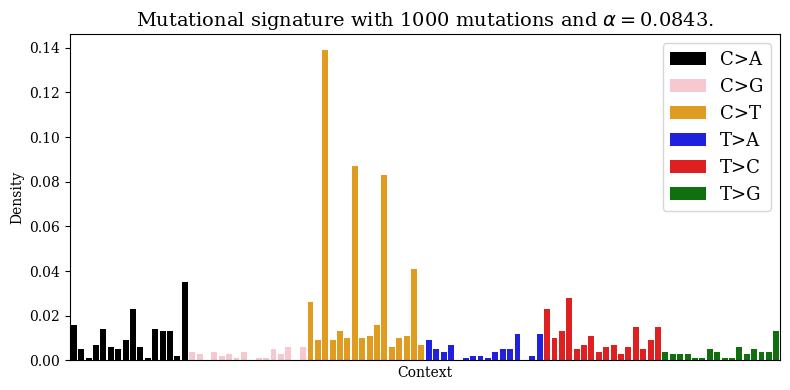

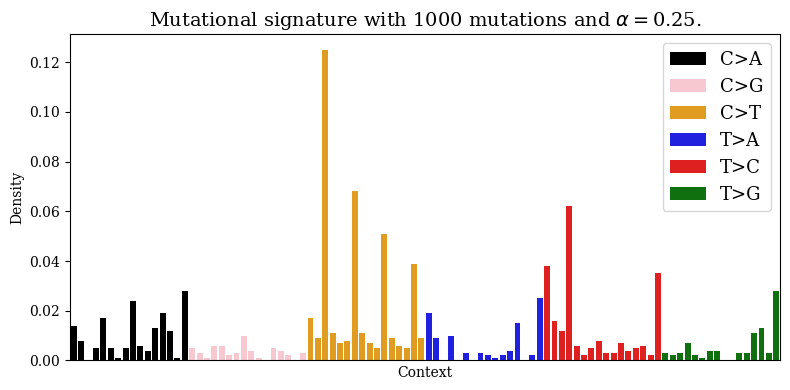

In [11]:
importlib.reload(synthetic_data);
contexts = clean_sig_df["Context"]
mutations = clean_sig_df["Mutation"]

# Infected profile alpha = 0.0843
alpha0843_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.0843)
alpha25_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.25)

N_muts = 1000
healthy_sig = synthetic_data.generate_signature(healthy_profile, N_muts)
infected_sig = synthetic_data.generate_signature(alpha0843_profile, N_muts)
infected_sig2 = synthetic_data.generate_signature(alpha25_profile, N_muts)

synthetic_data.plot_signature(contexts, mutations, healthy_sig, N_muts = 1000, alpha = 0.0)
synthetic_data.plot_signature(contexts, mutations, infected_sig, N_muts = 1000, alpha = 0.0843)
synthetic_data.plot_signature(contexts, mutations, infected_sig2, N_muts = 1000, alpha = 0.25)

Because SBS88 is dominated by T>C mutations, low levels of $\alpha$ make the signature **as a whole, across all 96 contexts** very similar. It might be worth doing the analysis **just on the T>C contexts**? Think this is something Xell suggested a few weeks ago.

Also: should store information for the mutational profiles of commonly used values of $\alpha$. Same goes for the tolerances.

In [ ]:
importlib.reload(synthetic_data);
mutational_profiles = synthetic_data.create_mutational_profiles(healthy_profile, sbs88_profile)
mutational_profiles.keys()
# NOTE Should revisit the tolerance finding and save that data too
# (takes about 5mins to run).

dict_keys([0, 0.0843, 0.1, 0.25, 0.5, 0.8, 1])

#### 4. Constructing confidence intervals using ABC-alpha rejection.

Currently we can plot the posterior, but all inference is done visually. We want to have a formal metric that says "$\alpha$ is very likely to be in THIS RANGE", i.e. a form of confidence interval.

Search "highest density interval".

True alpha =  0.25, lots of mutations (500).


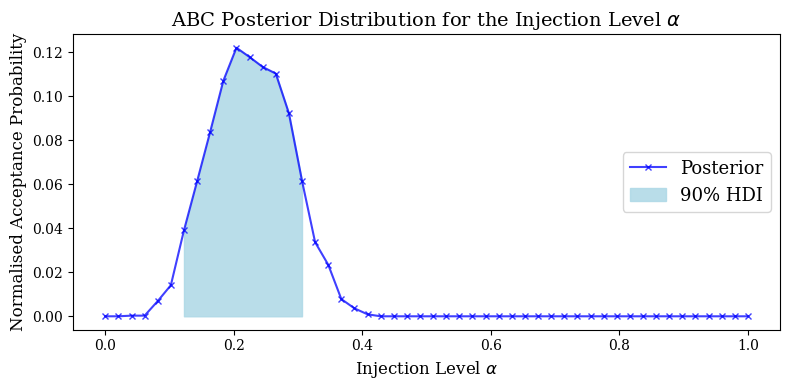

In [72]:
# EXAMPLE of posterior found from the abc-alpha.
# Tolerance found by inspection of earlier plots.
importlib.reload(abc_models);
alpha_test = 0.25; N_muts_test = 500; tol_test = 0.05;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, lots of mutations ({N_muts_test}).")
acceptances, alpha_range, alpha0, alpha1, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, plot = True)

In [73]:
importlib.reload(abc_models);
abc_models.hdi(acceptances, alpha_range)

(np.float64(0.12244897959183673),
 np.float64(0.3061224489795918),
 np.float64(0.9088995790739628))

True alpha =  0.0843, small number of mutations (100).


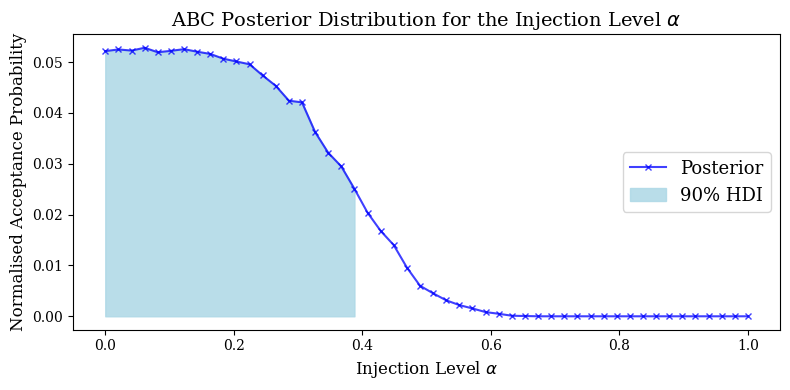

In [74]:
alpha_test = 0.0843; N_muts_test = 100; tol_test = 0.25;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, small number of mutations ({N_muts_test}).")
acceptances, alpha_range, alpha0, alpha1, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, plot = True)

True alpha =  0.0843, very large number of mutations (2000).
In this example we use more bins for alpha (100 instead of 50).


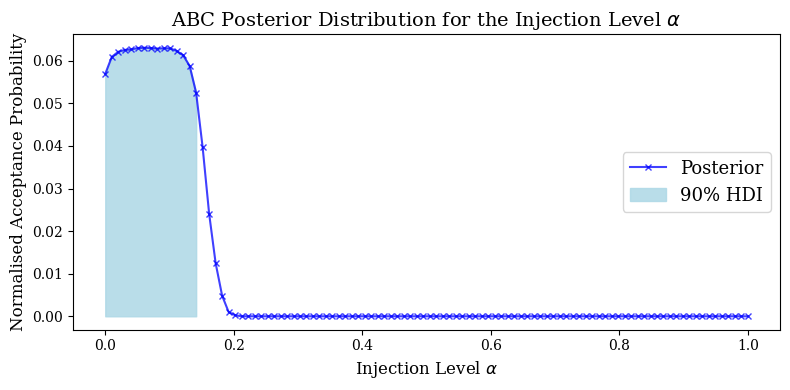

Interval [0.0, 0.14], containing total mass of 90.0%.


In [77]:
alpha_test = 0.0843; N_muts_test = 2000; tol_test = 0.015;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, very large number of mutations ({N_muts_test}).")
print(rf"In this example we use more bins for alpha (100 instead of 50).")
acceptances, alpha_range, alpha0, alpha1, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, a_bins = 100, plot = True)
print(rf"Interval [{round(alpha0, 2)}, {round(alpha1, 2)}], containing total mass of {round(100*hdi_mass, 3)}%.")

- In the first example, the HDI is far away from zero, so we'd detect the presence of SBS88. 
- In the second example, the HDI includes zero, but also values away from zero, so we'd be wary of detecting any SBS88.
- In the third example, we sometimes include zero, but aren't far from it. Here we'd suggest presence of SBS88 but not be *as* confident about it.

In [76]:
# NOTE Maybe also include the posterior mode in the statistics?